In [5]:
import math
import random as rn
import numpy as np
from copy import deepcopy
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

In [6]:
episode_durations = []
loss_list = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [7]:
from grid_vis_new import run_grid
from board_cell_classes import DQN, ReplayMemory, DLGrid

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class DLGridNotebook(DLGrid):
    def reset(self):
        episode_durations.append(int(self.score))
        plot_durations()
        super().reset()

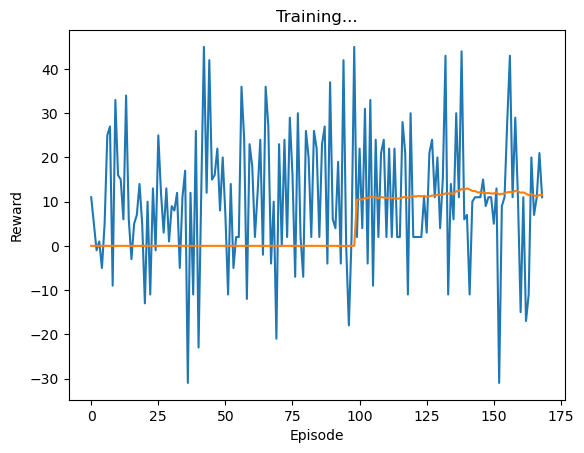

<Figure size 640x480 with 0 Axes>

In [ ]:
grid =  DLGridNotebook((18, 18))
grid.run_n_episodes(n=2000, vis=False)

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()